# Week 12 · Day 1 — Positional Encoding

## Why this matters

Transformers don’t have recurrence or convolution, so they need another way to know *order*.
**Positional encoding** injects sequence order into embeddings, letting models reason about position.

---

## Theory Essentials

* Transformers process tokens **in parallel** (not step by step).
* Need positional info: otherwise “dog bites man” = “man bites dog.”
* Two common approaches:

  * **Sinusoidal encoding** (fixed, based on sine/cosine).
  * **Learned encoding** (trainable parameters).
* Formula (sinusoidal):

  $$
  PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right), \quad
  PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
  $$
* Key property: allows model to generalize to unseen sequence lengths.



* Each **token embedding** is already a high-dimensional vector (say 512 or 768 values) that encodes meaning.
* Each **positional encoding vector** is the same size, but it only carries information about order.
* You **add them element-wise** → the result is still one vector of the same size, but now it encodes both *meaning* **and** *position*.

So for example (super simplified with 3 dimensions):

```
token embedding:        [0.3, 0.8, -0.1]   ← meaning of "dog"
positional encoding:    [0.1, -0.2, 0.05]  ← this is "position 2"
------------------------------------------------
final vector:           [0.4, 0.6, -0.05]
```

The model never sees “position” separately. It just learns from the *combined* vectors.


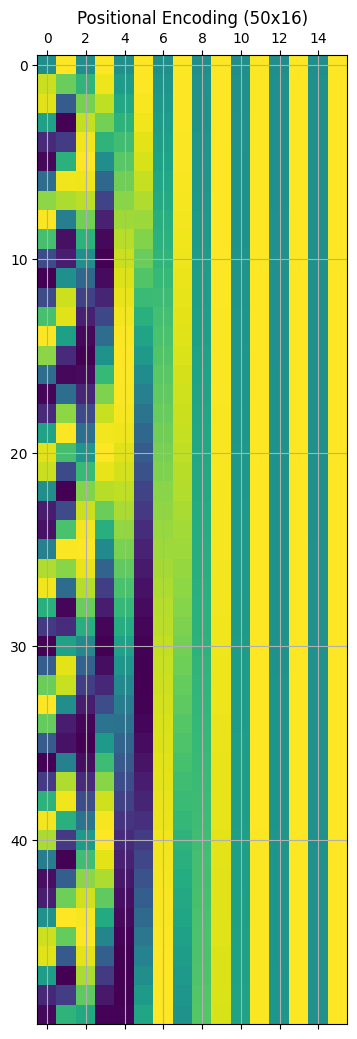

In [1]:
# Setup
import numpy as np, pandas as pd, matplotlib.pyplot as plt
np.random.seed(42)
plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams["axes.grid"] = True

import torch
import math

def positional_encoding(seq_len, d_model):
    pos = torch.arange(seq_len).unsqueeze(1)        # [seq_len, 1]
    i = torch.arange(d_model).unsqueeze(0)          # [1, d_model]
    angle_rates = 1 / (10000 ** (2*(i//2) / d_model))
    angles = pos * angle_rates                      # broadcasting
    
    PE = torch.zeros(seq_len, d_model)
    PE[:, 0::2] = torch.sin(angles[:, 0::2])
    PE[:, 1::2] = torch.cos(angles[:, 1::2])
    return PE

# Example: seq length = 50, d_model = 16
PE = positional_encoding(50, 16)
plt.matshow(PE.numpy(), cmap="viridis")
plt.title("Positional Encoding (50x16)")
plt.show()


Each row = one positional encoding vector (for positions 0 → 49).

Each vector has 16 numbers (since d_model=16).

The color is just a visual trick: yellow ≈ +1, dark purple ≈ –1, with shades in between.

So the heatmap is literally a “table of 50 vectors,” where color helps you spot the sine/cosine wave patterns across dimensions.

1) Core (10–15 min)
Task: Generate positional encodings for seq_len=100, d_model=32 and plot.

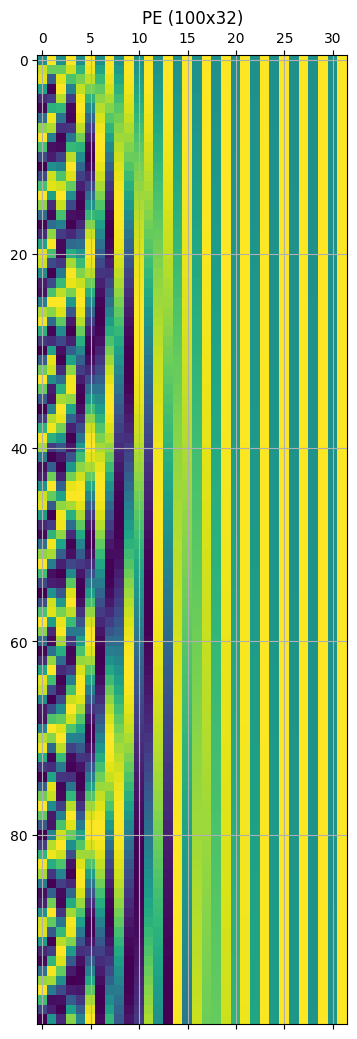

In [2]:
PE = positional_encoding(100, 32)
plt.matshow(PE.numpy(), cmap="viridis")
plt.title("PE (100x32)")
plt.show()


2) Practice (10–15 min)
Task: Compare sinusoidal vs learned positional encodings (random init).

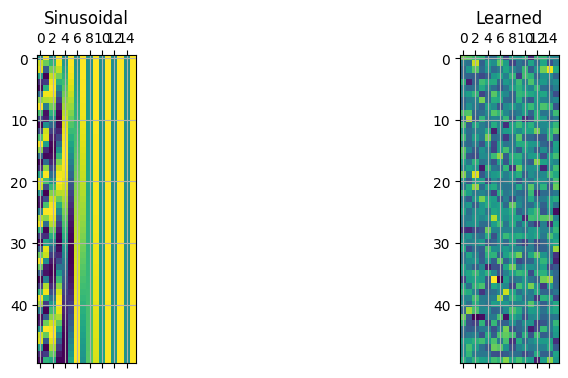

In [4]:
PE = positional_encoding(50, 16)

seq_len, d_model = 50, 16
learned = torch.nn.Embedding(seq_len, d_model)
LE = learned(torch.arange(seq_len))

fig, axs = plt.subplots(1,2, figsize=(10,4))
axs[0].matshow(PE.numpy(), cmap="viridis"); axs[0].set_title("Sinusoidal")
axs[1].matshow(LE.detach().numpy(), cmap="viridis"); axs[1].set_title("Learned")
plt.show()


3) Stretch (optional, 10–15 min)
Task: Verify that sinusoidal encoding is periodic — plot the first two dimensions across positions.

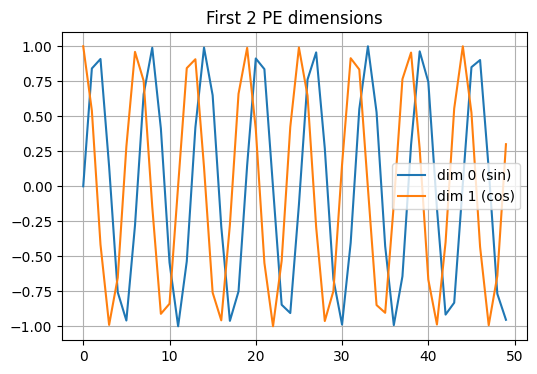

In [5]:
plt.plot(PE[:,0], label="dim 0 (sin)")
plt.plot(PE[:,1], label="dim 1 (cos)")
plt.legend(); plt.title("First 2 PE dimensions")
plt.show()


👉 What you did in the code:

Took the positional encoding matrix (shape: 50×16).

Selected column 0 (the first dimension of all 50 positions).

Selected column 1 (the second dimension of all 50 positions).

Plotted both across sequence positions 0–49.

👉 What the plot shows:

The x-axis = the token position in the sequence (0 → 50).

The y-axis = the encoding value for that position in a given dimension (between –1 and 1).

Blue line (dim 0) = sine wave pattern.

Orange line (dim 1) = cosine wave pattern.

So you’re literally looking at the first two coordinates of the positional encoding vectors as the position increases.

👉 Why it matters:

Each dimension of the encoding is a sinusoid with a different frequency.

This makes the representation periodic: after some number of steps, values repeat (like sine and cosine always do).

Combining many dimensions with different frequencies gives every position a unique fingerprint that also encodes relative distance.

Mini-Challenge (≤40 min)

Build a Positional Encoding Visualizer.

Input: sequence length L, embedding dim d.

Output: heatmap of encodings + line plots of first 4 dimensions.

Acceptance Criteria:

Clear heatmap for any L, d.

At least 4 positional dimensions plotted vs index.

Short explanation of what patterns you see.

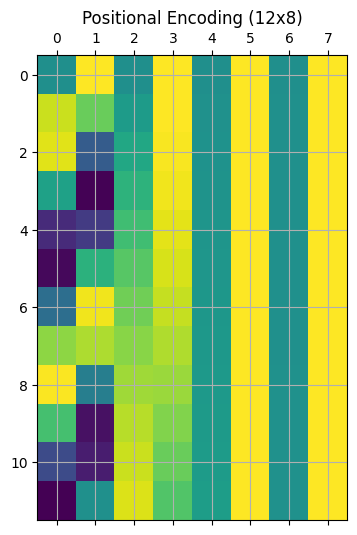

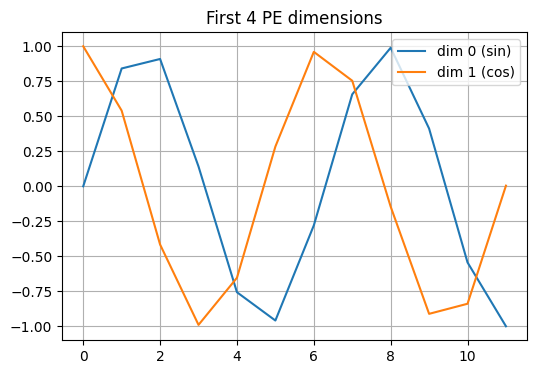

In [9]:
seq_len = int(input("Enter length of sequence: "))
dim = int(input("Enter dimension: "))


def positional_encoding_ch(seq_len, d_model):
    pos = torch.arange(seq_len).unsqueeze(1)        
    i = torch.arange(d_model).unsqueeze(0)          
    angle_rates = 1 / (10000 ** (2*(i//2) / d_model))
    angles = pos * angle_rates                      
    
    PE = torch.zeros(seq_len, d_model)
    PE[:, 0::2] = torch.sin(angles[:, 0::2])
    PE[:, 1::2] = torch.cos(angles[:, 1::2])
    return PE


PE = positional_encoding_ch(seq_len, dim)
plt.matshow(PE.numpy(), cmap="viridis")
plt.title(f"Positional Encoding ({seq_len}x{dim})")
plt.show()


plt.plot(PE[:,0], label="dim 0 (sin)")
plt.plot(PE[:,1], label="dim 1 (cos)")
plt.legend(); plt.title("First 4 PE dimensions")
plt.show()


Notes / Key Takeaways

Transformers need positional encodings to recover word order.

Sinusoidal = deterministic, generalizes to longer sequences.

Learned = flexible, but tied to training length.

Encodings are added to token embeddings before attention.

Even dimensions use sine, odd use cosine.

Different frequencies → model can attend to both local & global order.

Reflection

Why can’t Transformers rely only on embeddings without position info?

In what situation might a learned positional encoding outperform sinusoidal?

1. Why can’t Transformers rely only on embeddings without position info?
Because embeddings only capture meaning of tokens, not their order.
Without positional info, the model sees dog bites man as identical to man bites dog → same set of vectors in different order. Since Transformers process all tokens in parallel, they need explicit positional signals to reason about sequence structure.

2. In what situation might a learned positional encoding outperform sinusoidal?
When the training data has a fixed max length and the model doesn’t need to generalize beyond it.

Learned encodings can adapt more flexibly to the dataset’s structure.

Example: in machine translation with sentences rarely longer than 100 tokens, a learned encoding may give slightly better performance because it tailors itself to that domain.

👉 Sinusoidal = better generalization to unseen lengths.
👉 Learned = potentially better performance on the training distribution.